# 02 · 实战篇：从证据包复现 E2 全部数字

本笔记本把 `reports/e2-window-audit.md` 里的**每一个关键数字**用代码重算一遍，
并配上图。读完/跑完你会得到：

1. 对证据包结构的完整认识（policy_requests / observer / transitions / join receipts）；
2. 一段可以反复复用的数据加载代码（与仓库 `scripts/e2_audit_window.py` 同源逻辑）；
3. 一批带 "✓/✗" 的自检——全部通过说明本报告数字可复现。

**运行要求**：Python + numpy + matplotlib，数据 < 5MB，全程 < 1 分钟，0 GPU。
数据不存在时会自动从仓库里的证据包解压（见下面第一个代码单元）。

> 如果对 `k`、`logprob`、`θ_B`、`canonical` 这些词还不熟，先看 `01-概念篇`。

In [1]:
import json
import math
import os
import glob
import zipfile
import collections
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams["font.sans-serif"] = ["Noto Sans CJK SC", "WenQuanYi Zen Hei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# ---------- 路径解析 ----------
def find_repo_root(start=None):
    """向上查找包含 'hsy-的分析/' 的目录；找不到再看两个常见位置。"""
    start = Path(start or Path.cwd()).resolve()
    for d in [start, *start.parents]:
        if (d / "hsy-的分析").is_dir():
            return d
    for cand in [Path.home() / "10-4-alpha-proof",
                 Path("/mnt/gloway/projects/10-4-alpha-proof")]:
        if (cand / "hsy-的分析").is_dir():
            return cand
    return None

E2 = Path(os.environ.get("E2_WORK", "~/e2-work")).expanduser()
TRAIN = E2 / "training/remote/tmp/fate-m-formal-w001-shared-rollout-v2"
JOIN  = E2 / "join/remote/tmp/fate-m-formal-w001-join-v2/joins"
TRANS = (E2 / "training/remote/mnt/workspace/experiments/"
         "fate_m_20x200_ce_vs_online_v2_7b_20261005/runs/formal-20x10/"
         "wave_001/ce/update/replay/transitions.jsonl")

def ensure_data():
    """数据不在就自动解压证据包（幂等，重复执行安全）。"""
    if TRAIN.is_dir() and JOIN.is_dir():
        return "已就绪"
    repo = find_repo_root()
    assert repo is not None, "找不到仓库根目录（应包含 hsy-的分析/）"
    ev = repo / "hsy-的分析/extracted/modelscope_ce_online_delivery_20261006/evidence"
    for sub, name in [("training", "training_initial_evidence_20261006.zip"),
                      ("join", "join_v2_evidence_20261006.zip")]:
        zp = ev / name
        assert zp.exists(), f"缺少证据包：{zp}"
        E2.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zp) as z:
            z.extractall(E2 / sub)
    return "已从证据包解压"

print("E2 工作目录 :", E2)
print("数据状态    :", ensure_data())
print("仓库根目录  :", find_repo_root())

E2 工作目录 : /home/a/e2-work
数据状态    : 已就绪
仓库根目录  : /mnt/gloway/projects/10-4-alpha-proof


---
## 1. 数据导览

```text
~/e2-work/
├── training/remote/tmp/fate-m-formal-w001-shared-rollout-v2/
│   └── fate_m_XXX_v001/                        ← 20 道题，每题目录下：
│       ├── actor_receipts/…/policy_requests/   ← 1 个文件 = 64 个采样候选 + 每 token logprob
│       ├── observer.jsonl                      ← 搜索过程事件流（生成/执行/验证/选中）
│       └── attempts/attempt_01/…               ← 同上结构（单次尝试的副本）
├── training/remote/mnt/workspace/experiments/…/wave_001/ce/update/replay/
│   └── transitions.jsonl                       ← CE 实际使用的 20 条训练样本
└── join/…/joins/<problem>/strict-replay/      ← 严格重放验证回执
```

先确认 20 题的文件都在：

In [2]:
problems = sorted(d.name for d in TRAIN.iterdir() if d.name.startswith("fate_m_"))
print(f"题目数量            : {len(problems)}  （{problems[0]} … {problems[-1]}）")
print(f"observer.jsonl 数量 : {len(list(TRAIN.glob('*/observer.jsonl')))}")
print(f"策略请求文件数量    : {len(list(TRAIN.glob('*/actor_receipts/*/policy_requests/*.json')))}")
print(f"transitions.jsonl 是否存在: {TRANS.exists()}")

题目数量            : 20  （fate_m_003_v001 … fate_m_076_v001）
observer.jsonl 数量 : 20
策略请求文件数量    : 20
transitions.jsonl 是否存在: True


---
## 2. 解剖一次策略请求（policy_requests）

每个文件 = 一次请求 × 64 个采样。逐字段看一条候选：

In [3]:
def load_request(p):
    """读取某题的策略请求 JSON。"""
    reqs = sorted(glob.glob(str(TRAIN / p / "actor_receipts" / "*" / "policy_requests" / "*.json")))
    assert len(reqs) == 1, (p, len(reqs))
    return json.loads(Path(reqs[0]).read_text())

p0 = "fate_m_003_v001"
req0 = load_request(p0)
cands0 = req0["candidates"]

print(f"== {p0} ==")
print("候选数量:", len(cands0))
print("生成参数:", {k: req0["generation_contract"][k] for k in ("temperature", "top_p", "num_return_sequences", "max_new_tokens")})
print()
c0 = cands0[0]
print("单条候选的字段:", sorted(c0.keys()))
print()
print("文本             :", repr(c0["returned_text"]))
print("token ids        :", c0["raw_completion_token_ids"])
print("old  logprobs    :", [round(x, 3) for x in c0["raw_completion_old_logprobs"]])
print("samp logprobs    :", [round(x, 3) for x in c0["raw_completion_sampling_logprobs"]])

== fate_m_003_v001 ==
候选数量: 64
生成参数: {'temperature': 1.5, 'top_p': 0.9, 'num_return_sequences': 64, 'max_new_tokens': 512}

单条候选的字段: ['candidate_index', 'finish_reason', 'generation_params_sha256', 'gpu_seconds', 'raw_completion_old_logprobs', 'raw_completion_sampling_logprobs', 'raw_completion_token_ids', 'request_id', 'request_seed', 'returned_text', 'service_candidate_sha256', 'wall_seconds']

文本             : 'exact curry_target'
token ids        : [46385, 54078, 11123, 151643]
old  logprobs    : [-0.009, -0.192, -0.0, -0.0]
samp logprobs    : [0.0, -2.147, 0.0, 0.0]


两个 logprob 数组都是 **token 级**的，序列 logprob = 求和。

交叉验证：管线在 `observer.jsonl` 的 `generation` 事件里存了它当时使用的 `raw_logprob`，
应该等于该候选对应样本的 `Σ old_logprobs`：

In [4]:
# observer 的 generation 事件（key=canonical candidate_index）
gen = {}
for line in (TRAIN / p0 / "observer.jsonl").read_text().splitlines():
    ev = json.loads(line)
    if ev.get("kind") == "generation":
        gen[int(ev["candidate_index"])] = ev

# 复用一个最小加载器找 canonical #0 的 survivor 样本号
def load_problem(p):
    """把 policy_requests + observer 合并成 canonical 候选行（完整逻辑见 §4）。"""
    cands = load_request(p)["candidates"]
    canon, results, selected = {}, {}, None
    for line in (TRAIN / p / "observer.jsonl").read_text().splitlines():
        ev = json.loads(line)
        kind = ev.get("kind")
        if kind == "canonical_candidate":
            canon[ev["candidate_index"]] = ev
        elif kind == "canonical_candidate_result":
            results[ev["candidate_index"]] = ev
        elif kind == "canonical_selected_path":
            selected = ev
    sel_ids = set(selected.get("selected_event_ids", [])) if selected else set()
    rows = []
    for ci, ev in canon.items():
        res = results.get(ci, {})
        rc = cands[ev["survivor_sample_index"]]
        rows.append({
            "problem": p,
            "ci": ci,
            "action": ev["action"],
            "k": len(ev["sample_indices"]),
            "survivor": ev["survivor_sample_index"],
            "logp_old": sum(rc["raw_completion_old_logprobs"]),
            "logp_samp": sum(rc["raw_completion_sampling_logprobs"]),
            "status": res.get("verifier_status"),
            "did_execute": bool(res.get("did_execute")),
            "selected": ev.get("event_id") in sel_ids,
            "sequence": int(ev.get("sequence", 0)),
            "event_id": ev.get("event_id"),
        })
    return rows, selected

rows0, _ = load_problem(p0)
r0 = next(r for r in rows0 if r["ci"] == 0)
s_recomputed = sum(cands0[r0["survivor"]]["raw_completion_old_logprobs"])
g_observer = gen[0]["raw_logprob"]
print(f"canonical #0 的 survivor 样本号   = {r0['survivor']}")
print(f"receipt 里 Σ old_logprobs（重算）  = {s_recomputed:.6f}")
print(f"observer 里 raw_logprob（管线记录）= {g_observer:.6f}")
print("两者一致:", abs(s_recomputed - g_observer) < 1e-6)

canonical #0 的 survivor 样本号   = 60
receipt 里 Σ old_logprobs（重算）  = -5.951464
observer 里 raw_logprob（管线记录）= -5.951464
两者一致: True


再看一眼"语义去重"的效果：64 个原始样本里有几种不同文本？

In [5]:
texts = [c["returned_text"] for c in cands0]
cnt = collections.Counter(texts)
print(f"64 个原始样本 → {len(cnt)} 种不同文本。最高频 5 种：")
for t, n in cnt.most_common(5):
    print(f"  {n:>2}×  {t[:60]!r}")
print()
print("注意：模型最高频的 'exact curry_target' 是**错误拼写**，"
      "正确的 'exact curriculum_target' 只占少数——这是后面'高频≠正确'的伏笔。")

64 个原始样本 → 9 种不同文本。最高频 5 种：
  44×  'exact curry_target'
   9×  'exact curriculum_target'
   4×  'exact cardinal_target'
   2×  'exact curvature_target'
   1×  'exact hurwitz_surjective_comp hf hg'

注意：模型最高频的 'exact curry_target' 是**错误拼写**，正确的 'exact curriculum_target' 只占少数——这是后面'高频≠正确'的伏笔。


---
## 3. 解剖 observer（事件流）

`observer.jsonl` 每一行是一个事件。逐类看数量与字段：

In [6]:
kinds = collections.Counter()
for line in (TRAIN / p0 / "observer.jsonl").read_text().splitlines():
    kinds[json.loads(line).get("kind")] += 1
print("事件类型直方图:", dict(sorted(kinds.items())))
print()

canon_events = [json.loads(l) for l in (TRAIN / p0 / "observer.jsonl").read_text().splitlines()
                if json.loads(l).get("kind") == "canonical_candidate"]
e = canon_events[0]
print("一个 canonical_candidate 事件的关键字段：")
for key in ["candidate_index", "action", "sample_indices", "survivor_sample_index", "sequence", "event_id"]:
    val = str(e.get(key))
    print(f"  {key:24} = {val[:90]}")

事件类型直方图: {'canonical_candidate': 9, 'canonical_candidate_result': 9, 'canonical_selected_path': 1, 'checkpoint': 1, 'eval': 9, 'generation': 9, 'selection': 1}

一个 canonical_candidate 事件的关键字段：
  candidate_index          = 0
  action                   = exact current_target
  sample_indices           = [60]
  survivor_sample_index    = 60
  sequence                 = 1
  event_id                 = candidate:policy-fate_m_003_v001-00000001-00910dad599147ba86735d4fdc3a4412:0:0:60


关键理解：

- `canonical_candidate.sample_indices` → 命中的原始样本号 → **长度就是 k**；
- `survivor_sample_index` → 代表样本（其 logprob 被管线用作该候选的 `raw_logprob`）；
- `canonical_candidate_result.verifier_status` → `verified_proof` / `invalid_tactic`；
- `canonical_selected_path.selected_event_ids` → 被选进 CE 训练的那条路径。

---
## 4. 构建统一数据表

把 20 题的 `policy_requests + observer` 合成一张"canonical 候选表"。
每一行一条候选，字段如下（与 `scripts/e2_audit_window.py` 完全一致）：

In [7]:
def iter_problems():
    return sorted(d.name for d in TRAIN.iterdir() if d.name.startswith("fate_m_"))

ALL = []
for p in iter_problems():
    rows, _ = load_problem(p)
    ALL.extend(rows)

print("canonical 候选总数:", len(ALL))
print()
print("样例行：")
for k, v in ALL[0].items():
    print(f"  {k:>10}: {str(v)[:80]}")

canonical 候选总数: 233

样例行：
     problem: fate_m_003_v001
          ci: 0
      action: exact current_target
           k: 1
    survivor: 60
    logp_old: -5.951463815439638
   logp_samp: -5.980607032775879
      status: invalid_tactic
  did_execute: True
    selected: False
    sequence: 1
    event_id: candidate:policy-fate_m_003_v001-00000001-00910dad599147ba86735d4fdc3a4412:0:0:6


In [8]:
CHECKS = []
def check(name, got, want, tol=None):
    ok = abs(got - want) <= tol if tol is not None else got == want
    CHECKS.append((name, ok))
    print(("✓" if ok else "✗"), f"{name}: {got}" + ("" if ok else f"  （期望 {want}）"))

---
## 5. 总量核对（对齐交付文档）

交付文档声称：**1280 原始 draw / 233 唯一候选 / 49 次严格成功**。
我们独立重算：

In [9]:
n_raw = sum(len(load_request(p)["candidates"]) for p in iter_problems())
ver = [r for r in ALL if r["status"] == "verified_proof"]
inv = [r for r in ALL if r["status"] == "invalid_tactic"]
executed = [r for r in ALL if r["did_execute"]]
sel = [r for r in ALL if r["selected"]]

check("题目数量", len(list(iter_problems())), 20)
check("原始采样数（raw draws）", n_raw, 1280)
check("canonical 候选数", len(ALL), 233)
check("进入 Lean 执行数（did_execute）", len(executed), 170)
check("严格验证成功（verified_proof）", len(ver), 49)
check("失败（invalid_tactic）", len(inv), 184)
check("被选中 transition 数", len(sel), 20)

print()
print(f"解析阶段被拒（canonical 里没执行的）: {len(ALL) - len(executed)} 条")
print(f"去重比: {n_raw} → {len(ALL)} = {n_raw/len(ALL):.1f} : 1")
print(f"执行→验证成功率: {len(ver)}/{len(executed)} = {len(ver)/len(executed):.1%}")
print(f"raw→验证成功率: {len(ver)}/{n_raw} = {len(ver)/n_raw:.1%}")

✓ 题目数量: 20
✓ 原始采样数（raw draws）: 1280
✓ canonical 候选数: 233
✓ 进入 Lean 执行数（did_execute）: 170
✓ 严格验证成功（verified_proof）: 49
✓ 失败（invalid_tactic）: 184
✓ 被选中 transition 数: 20

解析阶段被拒（canonical 里没执行的）: 63 条
去重比: 1280 → 233 = 5.5 : 1
执行→验证成功率: 49/170 = 28.8%
raw→验证成功率: 49/1280 = 3.8%


---
## 6. 成功战术的命中次数分布（E2 核心图）

49 条成功在 64 次采样中的命中次数 `k` 分布：

verified 的 k 直方图: {1: 20, 2: 7, 3: 1, 4: 1, 5: 2, 6: 2, 8: 1, 9: 1, 10: 3, 11: 2, 12: 1, 13: 1, 14: 1, 16: 1, 17: 1, 23: 2, 25: 1, 37: 1}


/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20505 (\N{CJK UNIFIED IDEOGRAPH-5019}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 36873 (\N{CJK UNIFIED IDEOGRAPH-9009}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 26465 (\N{CJK UNIFIED IDEOGRAPH-6761}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20005 (\N{CJK UNIFIED IDEOGRAPH-4E25}) missing from font(s) 

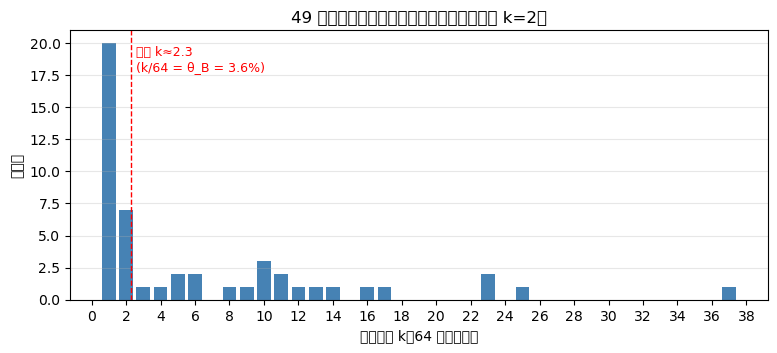


窗内（k/64 ≥ θ_B，即 k≥3）: 22/49
窗边/窗外（k≤2）          : 27/49
只出现 1 次（k=1）        : 20/49


In [10]:
B, DELTA = 64, 0.1
THETA = math.log(1 / DELTA) / B

khist = collections.Counter(r["k"] for r in ver)
print("verified 的 k 直方图:", dict(sorted(khist.items())))

ks = sorted(khist)
med_k = float(np.median([r["k"] for r in ver]))
plt.figure(figsize=(9, 3.5))
plt.bar(ks, [khist[k] for k in ks], width=0.8, color="steelblue")
plt.axvline(2.3, color="red", ls="--", lw=1)
plt.text(2.6, plt.ylim()[1]*0.85, "窗线 k≈2.3\n(k/64 = θ_B = 3.6%)", color="red", fontsize=9)
plt.xlabel("命中次数 k（64 次采样中）")
plt.ylabel("候选数")
plt.title(f"49 条严格成功战术的命中次数分布（中位数 k={med_k:g}）")
plt.xticks(range(0, 40, 2))
plt.grid(alpha=0.3, axis="y")
plt.show()

print()
print(f"窗内（k/64 ≥ θ_B，即 k≥3）: {sum(1 for r in ver if r['k']/B >= THETA)}/49")
print(f"窗边/窗外（k≤2）          : {sum(1 for r in ver if r['k'] <= 2)}/49")
print(f"只出现 1 次（k=1）        : {khist[1]}/49")

In [11]:
in_win_emp = sum(1 for r in ver if r["k"] / B >= THETA)
in_win_pm  = sum(1 for r in ver if math.exp(r["logp_old"]) >= THETA)
in_win_ps  = sum(1 for r in ver if math.exp(r["logp_samp"]) >= THETA)

print("三种口径下的'窗内'数量：")
print(f"  经验频率 k/64 ≥ θ_B : {in_win_emp}/49")
print(f"  记录 p_model ≥ θ_B  : {in_win_pm}/49")
print(f"  记录 p_samp ≥ θ_B   : {in_win_ps}/49")

print()
print("同预算（64 次）再跑一波的重发现概率（MLE 近似）：")
for kk in [1, 2, 6, 9]:
    print(f"  k={kk:>2}: {1 - (1 - kk/64)**64:.3f}")

三种口径下的'窗内'数量：
  经验频率 k/64 ≥ θ_B : 22/49
  记录 p_model ≥ θ_B  : 16/49
  记录 p_samp ≥ θ_B   : 15/49

同预算（64 次）再跑一波的重发现概率（MLE 近似）：
  k= 1: 0.635
  k= 2: 0.869
  k= 6: 0.998
  k= 9: 1.000


**读图要点**：

- 长尾在左：20/49 的成功只被采样到 **1 次**；
- 窗内只有 44.9%（22/49）——即"一半以上的成功来自分布的边缘"；
- 只出现一次的成功，换一波采样有约 37% 概率直接消失（重发现率 ≈ 63%）。

这就是 E2 判据树落到"**发现瓶颈**"分支的直接证据。

---
## 7. 被选中的 20 条 transition 与"选择规则"

先看明细表（对应报告 §3）：

In [12]:
sel_sorted = sorted(sel, key=lambda r: r["problem"])
print(f"{'problem':>22} {'k':>3} {'k/64':>6} {'-lg10 p_model':>14}   action")
for r in sel_sorted:
    print(f"{r['problem']:>22} {r['k']:>3} {r['k']/64:>6.3f} "
          f"{-r['logp_old']/math.log(10):>14.2f}   {r['action'][:52]}")

# 与 transitions.jsonl 交叉核对
trans = [json.loads(l) for l in TRANS.read_text().splitlines()]
check("transitions.jsonl 行数", len(trans), 20)
check("actions 多重集完全一致",
      collections.Counter(r["action"] for r in sel) == collections.Counter(t["action"] for t in trans),
      True)

               problem   k   k/64  -lg10 p_model   action
       fate_m_003_v001   9  0.141           1.44   exact curriculum_target
       fate_m_004_v001   6  0.094           1.71   exact curriculum_target
       fate_m_009_v001   1  0.016           7.10   simp only [curriculum_target, Nat.zero_add, zero_add
       fate_m_011_v001   1  0.016           4.24   exact (curriculum_target : a * (b - c) = a * b - a *
       fate_m_014_v001   1  0.016           3.15   simp only [curriculum_target, eq, zero_pow (Nat.succ
       fate_m_015_v001  23  0.359           0.65   exact curriculum_target
       fate_m_018_v001   1  0.016           3.28   apply curriculum_target
       fate_m_021_v001  14  0.219           0.58   exact curriculum_target
       fate_m_035_v001  10  0.156           0.74   exact curriculum_target
       fate_m_040_v001   1  0.016           2.77   exact fun z ↦ by tauto
       fate_m_048_v001  13  0.203           0.95   exact curriculum_target
       fate_m_051_v001   2  0.0

/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 34987 (\N{CJK UNIFIED IDEOGRAPH-88AB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 36890 (\N{CJK UNIFIED IDEOGRAPH-901A}) missing from font(s) 

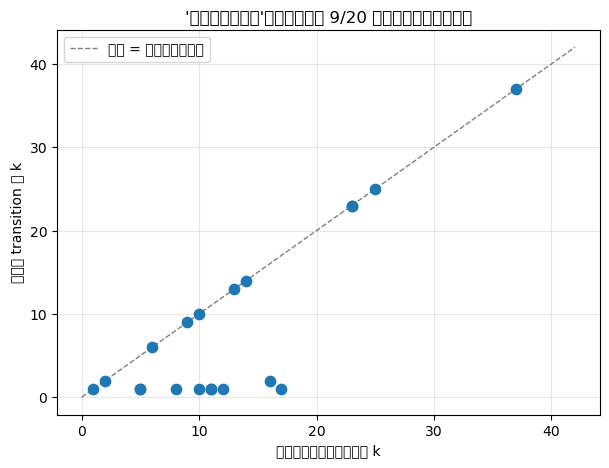

选中 ≠ 最高频 的题数: 9/20
  fate_m_009_v001: 选中 k=1，该题最高 k=5
  fate_m_011_v001: 选中 k=1，该题最高 k=5
  fate_m_014_v001: 选中 k=1，该题最高 k=11
  fate_m_018_v001: 选中 k=1，该题最高 k=10
  fate_m_040_v001: 选中 k=1，该题最高 k=8
  fate_m_051_v001: 选中 k=2，该题最高 k=16
  fate_m_052_v001: 选中 k=1，该题最高 k=17
  fate_m_061_v001: 选中 k=1，该题最高 k=12
  fate_m_068_v001: 选中 k=1，该题最高 k=11


In [13]:
# 每题：选中的 k vs 该题已验证候选的最高 k
sel_k, max_k = {}, {}
for p in iter_problems():
    rows, _ = load_problem(p)
    sel_k[p] = next(r["k"] for r in rows if r["selected"])
    max_k[p] = max(r["k"] for r in rows if r["status"] == "verified_proof")

plist = sorted(sel_k)
plt.figure(figsize=(7, 5))
plt.scatter([max_k[p] for p in plist], [sel_k[p] for p in plist], s=55, zorder=3)
lim = max(max(max_k.values()), 40) + 2
plt.plot([0, lim], [0, lim], color="gray", ls="--", lw=1, label="选中 = 该题最高频变体")
plt.xlabel("该题已验证候选中的最高 k")
plt.ylabel("被选中 transition 的 k")
plt.title("'第一个通过验证'的选择规则使 9/20 题选中了更稀有的变体")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

n_notmax = sum(1 for p in plist if sel_k[p] < max_k[p])
print(f"选中 ≠ 最高频 的题数: {n_notmax}/20")
for p in plist:
    if sel_k[p] < max_k[p]:
        print(f"  {p}: 选中 k={sel_k[p]}，该题最高 k={max_k[p]}")

In [14]:
# "第一个通过验证"规则：selected 的 sequence 应等于已验证候选中最小的 sequence
first_ok = 0
for p in iter_problems():
    rows, _ = load_problem(p)
    vseq = min(r["sequence"] for r in rows if r["status"] == "verified_proof")
    sseq = next(r["sequence"] for r in rows if r["selected"])
    first_ok += (vseq == sseq)
check("selected = 最早通过验证（按事件顺序）的题数", first_ok, 20)

✓ selected = 最早通过验证（按事件顺序）的题数: 20


**含义**：CE 的"硬目标"来自一个**顺序敏感**的规则——先被打到、先过验证的那条被选中，
与它的先验高低无关。对 k≤2 的题，换一波采样很可能会选中**另一个**变体。
这是 E5（软目标 vs 硬目标）实验最直接的动机。

---
## 8. logprob 校准（E2 §4）

把全部 233 条候选按记录的 `-log10(p_model)` 分桶，看桶内"经验频率"：

In [15]:
labels = ["[0,0.5)", "[0.5,1)", "[1,2)", "[2,4)", "[4+)"]

def which_bucket(x):
    if x < 0.5: return labels[0]
    if x < 1.0: return labels[1]
    if x < 2.0: return labels[2]
    if x < 4.0: return labels[3]
    return labels[4]

buckets = collections.defaultdict(list)
for r in ALL:
    x = -r["logp_old"] / math.log(10)
    buckets[which_bucket(x)].append(r["k"] / B)

print(f"{'桶':>10} {'n':>4} {'频率均值':>10} {'频率中位':>10}")
for lab in labels:
    vals = buckets[lab]
    print(f"{lab:>10} {len(vals):>4} {np.mean(vals):>10.4f} {np.median(vals):>10.4f}")

check("桶 [0,0.5) 的 n", len(buckets[labels[0]]), 22)
check("桶 [0.5,1) 的 n", len(buckets[labels[1]]), 12)
check("桶 [1,2) 的 n",   len(buckets[labels[2]]), 60)
check("桶 [2,4) 的 n",   len(buckets[labels[3]]), 110)
check("桶 [4+) 的 n",    len(buckets[labels[4]]), 29)

         桶    n       频率均值       频率中位
   [0,0.5)   22     0.5170     0.5078
   [0.5,1)   12     0.2044     0.2109
     [1,2)   60     0.0573     0.0469
     [2,4)  110     0.0206     0.0156
      [4+)   29     0.0162     0.0156
✓ 桶 [0,0.5) 的 n: 22
✓ 桶 [0.5,1) 的 n: 12
✓ 桶 [1,2) 的 n: 60
✓ 桶 [2,4) 的 n: 110
✓ 桶 [4+) 的 n: 29


/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) 

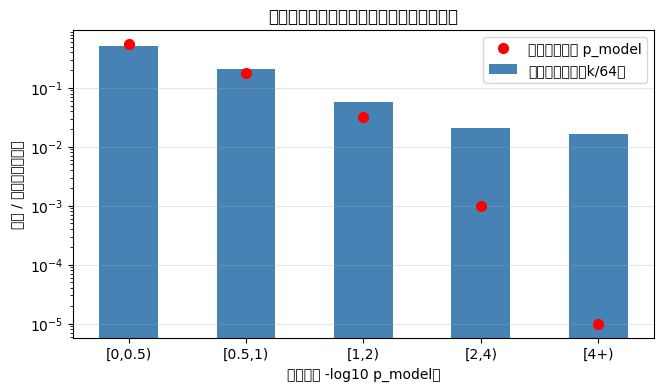

In [16]:
mids   = [0.25, 0.75, 1.5, 3.0, 5.0]
mfreq  = [float(np.mean(buckets[lab])) for lab in labels]
nominal = [10 ** (-m) for m in mids]        # 桶中点对应的"记录 p"

x = np.arange(len(labels))
plt.figure(figsize=(7.5, 4))
plt.bar(x, mfreq, width=0.5, color="steelblue", label="观测频率均值（k/64）")
plt.plot(x, nominal, "o", color="red", ms=7, label="桶中点的记录 p_model")
plt.yscale("log")
plt.xticks(x, labels)
plt.xlabel("桶（记录 -log10 p_model）")
plt.ylabel("概率 / 频率（对数轴）")
plt.title("校准检查：越靠右，记录值与观测差异越大")
plt.grid(alpha=0.3, axis="y")
plt.legend()
plt.show()

结论（与报告 §4 相同）：

- 前两桶（记录 p ≥ 10%）大体对得上；
- `[4+)` 桶：记录声称 `p < 1e-4`，但观测频率均值 ≈ 0.016（约 1/64）——
  如果记录准确，这些候选基本不该出现。

因此：**记录 logprob 不能当绝对采样概率用**；E2 的窗口分析以经验频率 k/64 为准。
对原因和影响的分析见 `03-深挖篇`。

---
## 9. 失败对照（E2 §5）

184 条失败候选 vs 49 条成功候选：

In [17]:
def stat(rows):
    freqs = [r["k"] / B for r in rows]
    lgs   = [-r["logp_old"] / math.log(10) for r in rows]
    return {
        "n": len(rows),
        "freq_mean": float(np.mean(freqs)),
        "freq_med": float(np.median(freqs)),
        "lg_med": float(np.median(lgs)),
        "inwin": sum(1 for r in rows if r["k"] / B >= THETA),
        "k1": sum(1 for r in rows if r["k"] == 1),
    }

sv, si = stat(ver), stat(inv)
print(f"{'指标':>18} {'verified':>10} {'invalid':>10}")
print(f"{'n':>18} {sv['n']:>10} {si['n']:>10}")
print(f"{'经验频率均值':>18} {sv['freq_mean']:>10.4f} {si['freq_mean']:>10.4f}")
print(f"{'经验频率中位':>18} {sv['freq_med']:>10.4f} {si['freq_med']:>10.4f}")
print(f"{'-lg10 p_model 中位':>18} {sv['lg_med']:>10.2f} {si['lg_med']:>10.2f}")
print(f"{'窗内（经验）':>18} {sv['inwin']:>10} {si['inwin']:>10}")
print(f"{'k=1 数量':>18} {sv['k1']:>10} {si['k1']:>10}")

check("invalid 的窗内数", si["inwin"], 53)
check("invalid 的 k=1 数量", si["k1"], 109)
check("verified 的 k=1 数量", sv["k1"], 20)

                指标   verified    invalid
                 n         49        184
            经验频率均值     0.0995     0.0822
            经验频率中位     0.0312     0.0156
  -lg10 p_model 中位       1.85       2.32
            窗内（经验）         22         53
            k=1 数量         20        109
✓ invalid 的窗内数: 53
✓ invalid 的 k=1 数量: 109
✓ verified 的 k=1 数量: 20


In [18]:
# 按 k 分组看成功率
tot = collections.Counter(r["k"] for r in ALL)
suc = collections.Counter(r["k"] for r in ver)

print(f"{'k':>3} {'总数':>5} {'成功':>5} {'成功率':>8}")
for kk in sorted(tot):
    print(f"{kk:>3} {tot[kk]:>5} {suc[kk]:>5} {suc[kk]/tot[kk]:>8.0%}")

check("k=1 的总数", tot[1], 129)
check("k=1 的成功数", suc[1], 20)

  k    总数    成功      成功率
  1   129    20      16%
  2    29     7      24%
  3    11     1       9%
  4    11     1       9%
  5     8     2      25%
  6     4     2      50%
  7     3     0       0%
  8     1     1     100%
  9     2     1      50%
 10     3     3     100%
 11     2     2     100%
 12     2     1      50%
 13     1     1     100%
 14     2     1      50%
 16     2     1      50%
 17     1     1     100%
 20     1     0       0%
 22     1     0       0%
 23     2     2     100%
 25     2     1      50%
 27     1     0       0%
 29     1     0       0%
 32     3     0       0%
 33     3     0       0%
 35     1     0       0%
 36     1     0       0%
 37     1     1     100%
 38     1     0       0%
 44     1     0       0%
 48     1     0       0%
 52     1     0       0%
 60     1     0       0%
✓ k=1 的总数: 129
✓ k=1 的成功数: 20


两个看似矛盾、其实一致的事实：

1. **先验高 → 成功率更高**（成功组 p_model 中位 10⁻¹·⁸⁶ vs 失败组 10⁻²·³²）；
2. **高频 ≠ 正确**：k=44 的 `exact curry_target` 全失败；k≥20 的 22 条样本只有 4 条成功。

模型最自信的输出常常是**错误的标识符拼写**（curry/cardinal/curvature…），
正确的 `curriculum_target` 反而落在低频区。所以**验证**（而不是先验排序）才是判别器，
这也是"搜索/多样采样不可被贪心解码替代"的原因。

---
## 10. 每题发现曲线（E2 §6）

问题：**如果预算缩水**（只抽 B' < 64 次），每道题还能找到至少 1 个成功吗？
用超几何分布 P(找到 | B') = 1 − C(64−K, B') / C(64, B') 计算，
其中 K 是该题**全部**成功样本数（同一战术的多次命中也算）。

In [19]:
def p_find(K, Bp, N=64):
    if K <= 0: return 0.0
    if Bp >= N: return 1.0
    return 1 - math.comb(N - K, Bp) / math.comb(N, Bp)

Kver = {}
for p in iter_problems():
    rows, _ = load_problem(p)
    Kver[p] = sum(r["k"] for r in rows if r["status"] == "verified_proof")

budgets = [4, 8, 16, 32, 64]
head = " ".join(f"{'B=' + str(b):>8}" for b in budgets)
print(f"{'problem':>22} {'K_ver':>6} {head}")
for p in iter_problems():
    vals = " ".join(f"{p_find(Kver[p], b):>8.3f}" for b in budgets)
    print(f"{p:>22} {Kver[p]:>6} {vals}")

check("f067 在 B=16 的 P(找到)", round(p_find(Kver['fate_m_067_v001'], 16), 4), 0.4405, tol=1e-3)
check("f076 在 B=16 的 P(找到)", round(p_find(Kver['fate_m_076_v001'], 16), 4), 0.6938, tol=1e-3)

               problem  K_ver      B=4      B=8     B=16     B=32     B=64
       fate_m_003_v001      9    0.463    0.725    0.939    0.999    1.000
       fate_m_004_v001      6    0.332    0.567    0.836    0.988    1.000
       fate_m_009_v001     12    0.574    0.830    0.979    1.000    1.000
       fate_m_011_v001      7    0.378    0.627    0.881    0.995    1.000
       fate_m_014_v001     26    0.884    0.989    1.000    1.000    1.000
       fate_m_015_v001     23    0.841    0.978    1.000    1.000    1.000
       fate_m_018_v001     12    0.574    0.830    0.979    1.000    1.000
       fate_m_021_v001     14    0.638    0.879    0.990    1.000    1.000
       fate_m_035_v001     10    0.502    0.765    0.957    1.000    1.000
       fate_m_040_v001     20    0.786    0.960    0.999    1.000    1.000
       fate_m_048_v001     13    0.607    0.856    0.985    1.000    1.000
       fate_m_051_v001     18    0.743    0.941    0.998    1.000    1.000
       fate_m_052_v001   

/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 33267 (\N{CJK UNIFIED IDEOGRAPH-81F3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 23569 (\N{CJK UNIFIED IDEOGRAPH-5C11}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 25214 (\N{CJK UNIFIED IDEOGRAPH-627E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 21040 (\N{CJK UNIFIED IDEOGRAPH-5230}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) 

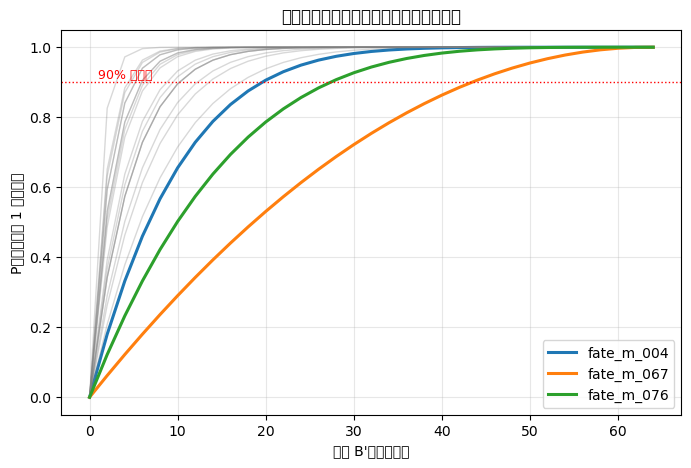

In [20]:
xs = np.arange(0, 65, 2)
highlight = {"fate_m_067_v001", "fate_m_076_v001", "fate_m_004_v001"}
plt.figure(figsize=(8, 5))
for p in iter_problems():
    ys = [p_find(Kver[p], int(b)) for b in xs]
    if p in highlight:
        plt.plot(xs, ys, lw=2.2, label=p.replace("_v001", ""))
    else:
        plt.plot(xs, ys, color="gray", alpha=0.3, lw=1)
plt.axhline(0.9, color="red", ls=":", lw=1)
plt.text(1, 0.91, "90% 把握线", color="red", fontsize=9)
plt.xlabel("预算 B'（次采样）")
plt.ylabel("P（至少找到 1 个成功）")
plt.title("每题发现曲线：预算缩水时哪些题先掉队")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

读法：

- B'=32 时所有题仍 ≥75%；B'=16 时 f067（44%）、f076（69%）、f004（84%）开始掉队；
- 对 E3（搜索 vs 采样）：tier-1 单步题上"搜索 ≈ 大 k 采样"，
  这条曲线就是**纯采样臂的基线**；真正的搜索增益要在多步题上测。

---
## 11. 收尾：自检汇总 + 结果落盘

In [21]:
summary = {
    "totals": {"raw": n_raw, "canonical": len(ALL), "executed": len(executed),
               "verified": len(ver), "invalid": len(inv), "selected": len(sel)},
    "theta_B": THETA,
    "verified_inwindow": {"empirical": in_win_emp, "p_model": in_win_pm, "p_samp": in_win_ps},
    "verified_k_histogram": dict(sorted(khist.items())),
    "selected_not_maxk": n_notmax,
    "verified_stats": sv,
    "invalid_stats": si,
    "k_ver": Kver,
}
out = E2 / "e2-notebook-recheck.json"
out.write_text(json.dumps(summary, ensure_ascii=False, indent=2))
print("已写出:", out)
print()

n_ok = sum(1 for _, ok in CHECKS if ok)
print(f"===== 自检结果: {n_ok}/{len(CHECKS)} 通过 =====")
for name, ok in CHECKS:
    if not ok:
        print("  ✗", name)

已写出: /home/a/e2-work/e2-notebook-recheck.json

===== 自检结果: 22/22 通过 =====


全部通过 = 报告数字可在你的机器上完整复现。

**下一站**：`03-深挖篇：口径、选择、预算`

- 选择规则的严格核验（first-verified / max-survivor）；
- logprob 失准的可视化（散点 + f009 逐 token 案例）；
- 预算 what-if（把 B' 当参数扫，找出每题的"90% 预算线"）。